In [499]:
%cd "C:\Users\asmaa\Desktop\Amr\Master's Thesis v0.4"

C:\Users\asmaa\Desktop\Amr\Master's Thesis v0.4


In [500]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [501]:
import devices
import models
import samplers
import trainers
import utils

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

In [502]:
memory_type = torch.device('cuda')
dtype = torch.float32
num_modes = 1
study = 'TE'

# device 1

In [503]:
# # parameters
# lambd = 1.55
# 
# # wave number and normalized spacing
# k_0 = 2 * np.pi / lambd
# 
# # device 1
# 
# # spacing
# dx = 0.05 * k_0
# dy = 0.05 * k_0
# 
# # simulation lengths
# core_length_x = 2 * k_0 # W
# core_length_y = 1 * k_0 # H
# 
# substrate_length_x = 3.0 * k_0 # Xs
# substrate_length_y = 3.0 * k_0 # Ys
# 
# # refractive indices
# n_core = 1.55
# n_substrate = 1.44

In [504]:
# parameters
lambd = 1.55

# wave number and normalized spacing
k_0 = 2 * np.pi / lambd

# device 2

# spacing
dx = 0.05 * k_0
dy = 0.05 * k_0

# simulation lengths
core_length_x = 1 * k_0 # W
core_length_y = 1 * k_0 # H

substrate_length_x = 3.0 * k_0 # Xs
substrate_length_y = 3.0 * k_0 # Ys

# refractive indices
n_core = 1.7
n_substrate = 1.2

In [505]:
weights = [1/2, 1/2, 4, 1/4, 1, 1]
m = 2

In [506]:
lengths_x = [substrate_length_x, core_length_x, substrate_length_x]
lengths_y = [substrate_length_y, core_length_y, substrate_length_y]
RIs = [n_substrate, n_core]

In [507]:
reference_device = devices.BuriedChannelWaveguide(RIs, lambd, lengths_x, lengths_y, study, 'E')

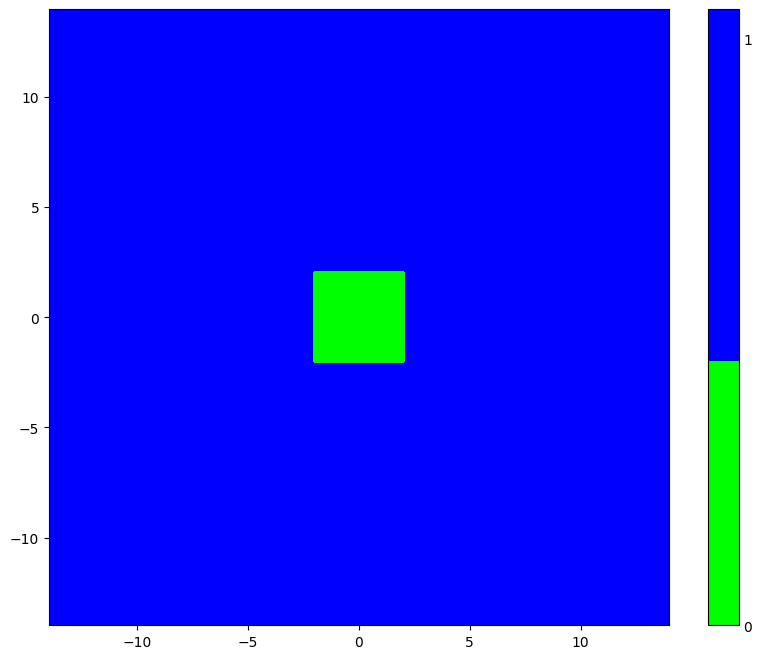

In [508]:
reference_device.plot(dx, dy)

In [509]:
torch.manual_seed(42)
base_model = models.discontinuity_capturing_network(2, 256, num_modes, 2, 'Siren')
optimizer = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[20000], gamma=1e0)
print('number of trainable parameters', sum([p.numel() for p in base_model.parameters() if p.requires_grad]))

number of trainable parameters 67073


In [511]:
# mesh = samplers.uniform_grid_2d(reference_device, dx/2, dy/2, dtype, 'cpu')
# features = reference_device.make_features(mesh)
# 
# plt.scatter(mesh[:, 0].cpu().detach(), mesh[:, 1].cpu().detach(), s=1, c=features, cmap='jet');

In [512]:
device = devices.BuriedChannelWaveguideWithPINNs(RIs, lambd, lengths_x, lengths_y, study, 'E', base_model, 1, True)

In [513]:
reference_device_fd = devices.BuriedChannelWaveguideWithFD(RIs, lambd, lengths_x, lengths_y, study, 'E', dx, dy)

In [514]:
train_agent = trainers.Trainer2D(dtype, device, reference_device_fd, memory_type, samplers.uniform_grid_2d, optimizer, scheduler, dx=dx, dy=dy, num_samples=None, n_lower=None, n_upper=None)

  0%|          | 0/20001 [00:00<?, ?it/s]

num samples 19321


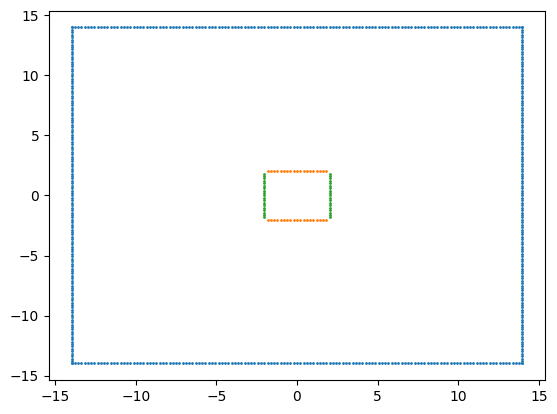

loss1 is 0.00288, loss2 is 0.00091, loss3 is 0.00296, loss4 is 0.0, loss5 is 0.04468, loss6 is 0.07628, total loss 0.12771, RI value 1.18524:   0%|          | 0/20001 [00:00<?, ?it/s]

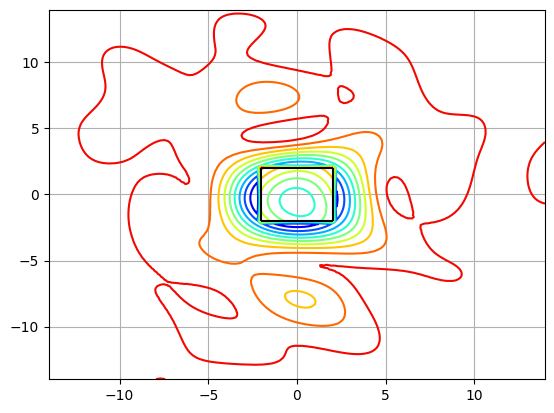

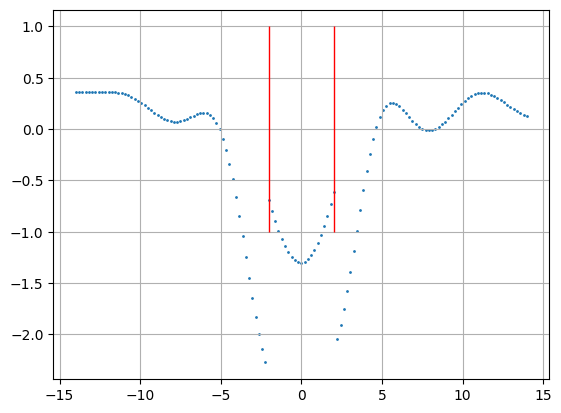

loss1 is 0.00064, loss2 is 0.00058, loss3 is 0.00042, loss4 is 0.0, loss5 is 1e-05, loss6 is 0.00125, total loss 0.00291, RI value 1.48103:   2%|▏         | 499/20001 [00:22<14:21, 22.64it/s]  

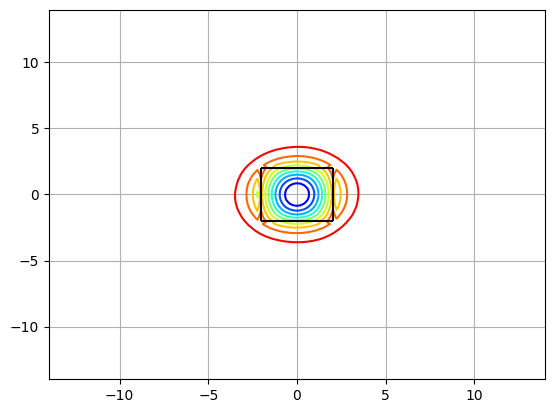

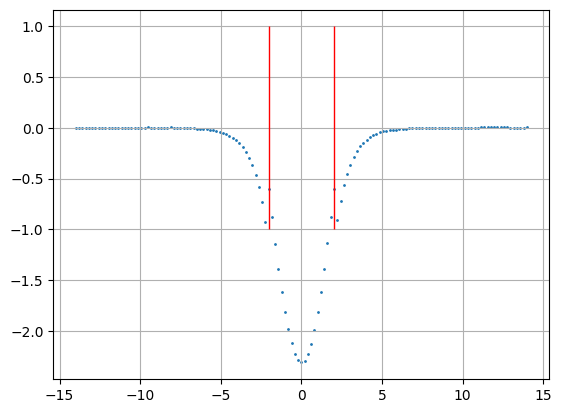

loss1 is 0.00064, loss2 is 0.00035, loss3 is 0.00042, loss4 is 0.0, loss5 is 0.0, loss6 is 0.0012, total loss 0.00262, RI value 1.48051:   5%|▍         | 1000/20001 [00:43<13:17, 23.83it/s]    

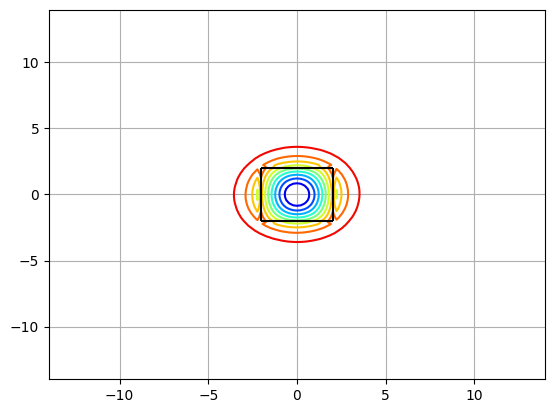

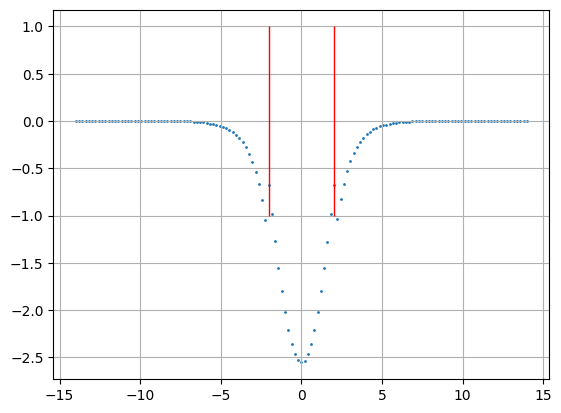

loss1 is 0.00039, loss2 is 0.00033, loss3 is 0.00025, loss4 is 0.0, loss5 is 0.00011, loss6 is 0.00118, total loss 0.00226, RI value 1.48162:   7%|▋         | 1498/20001 [01:05<13:16, 23.23it/s]

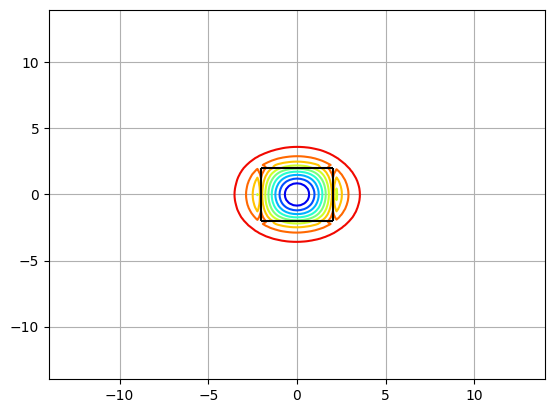

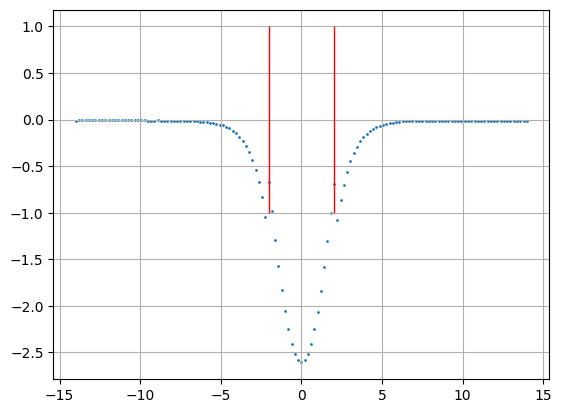

loss1 is 0.00038, loss2 is 0.00028, loss3 is 0.00025, loss4 is 0.0, loss5 is 8e-05, loss6 is 0.00115, total loss 0.00215, RI value 1.4823:  10%|▉         | 1999/20001 [01:27<12:34, 23.87it/s]   

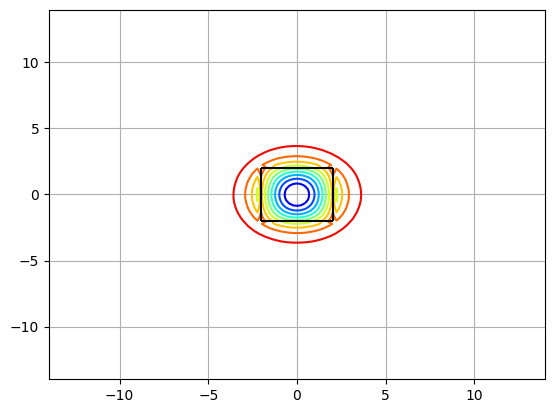

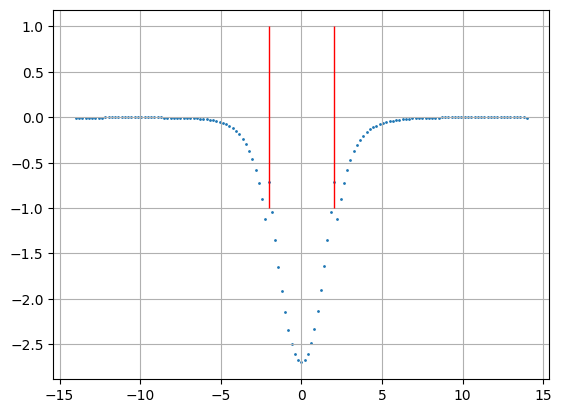

loss1 is 0.0003, loss2 is 0.00026, loss3 is 0.0002, loss4 is 0.0, loss5 is 3e-05, loss6 is 0.00117, total loss 0.00195, RI value 1.48298:  12%|█▏        | 2500/20001 [01:48<12:23, 23.53it/s]    

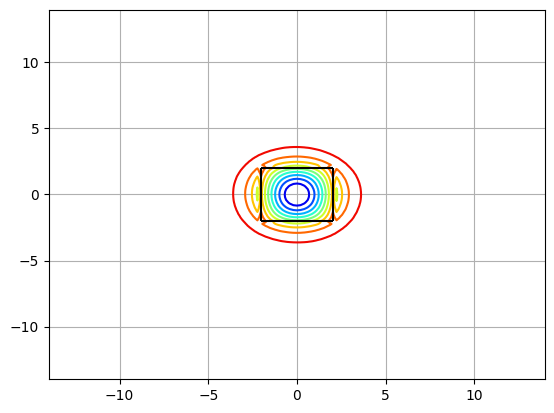

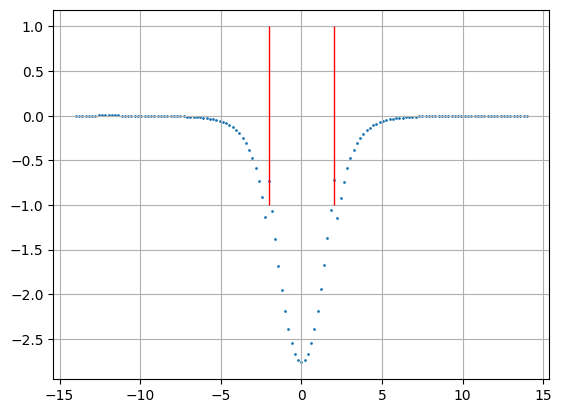

loss1 is 0.00051, loss2 is 0.00023, loss3 is 0.00033, loss4 is 0.0, loss5 is 0.00045, loss6 is 0.00115, total loss 0.00267, RI value 1.48313:  15%|█▍        | 2998/20001 [02:10<12:38, 22.40it/s]

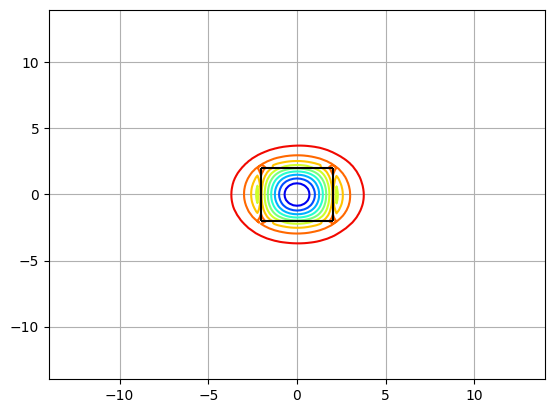

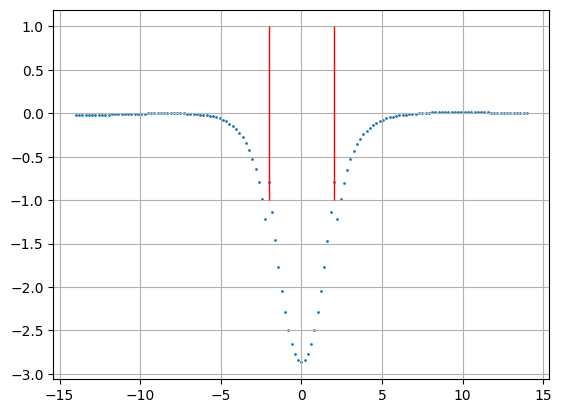

loss1 is 0.00043, loss2 is 0.00024, loss3 is 0.00028, loss4 is 0.0, loss5 is 1e-05, loss6 is 0.00114, total loss 0.0021, RI value 1.48215:  17%|█▋        | 3499/20001 [02:32<11:42, 23.49it/s]   

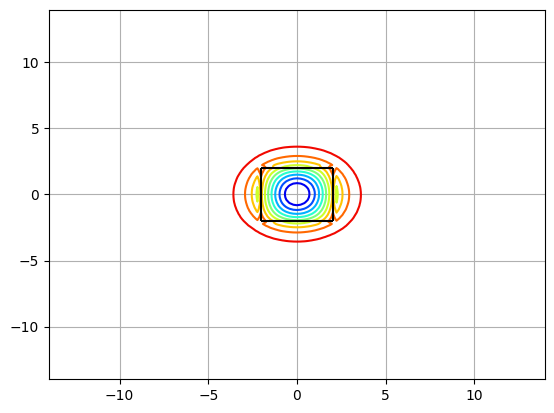

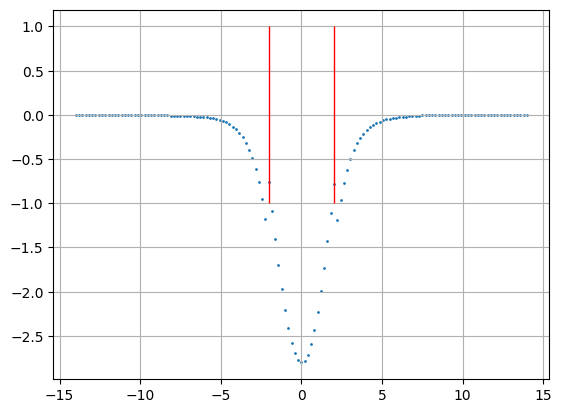

loss1 is 0.00034, loss2 is 0.00026, loss3 is 0.00023, loss4 is 0.0, loss5 is 5e-05, loss6 is 0.00118, total loss 0.00206, RI value 1.48296:  20%|█▉        | 4000/20001 [02:53<11:11, 23.81it/s]  

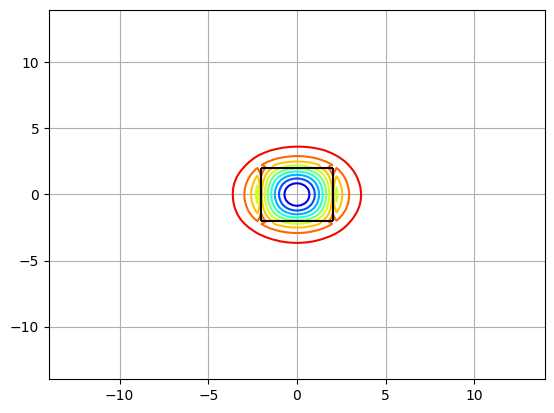

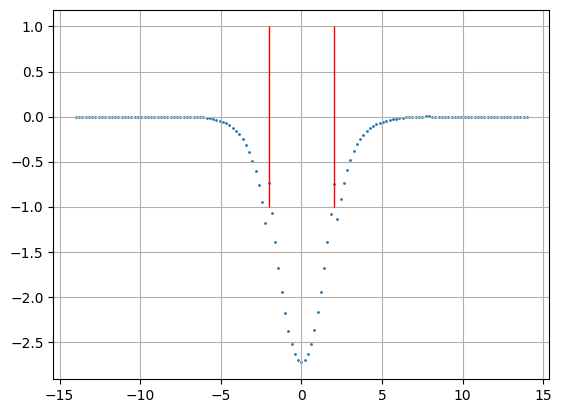

loss1 is 0.00036, loss2 is 0.00024, loss3 is 0.00024, loss4 is 0.0, loss5 is 4e-05, loss6 is 0.00108, total loss 0.00195, RI value 1.48381:  22%|██▏       | 4498/20001 [03:14<10:47, 23.95it/s]  

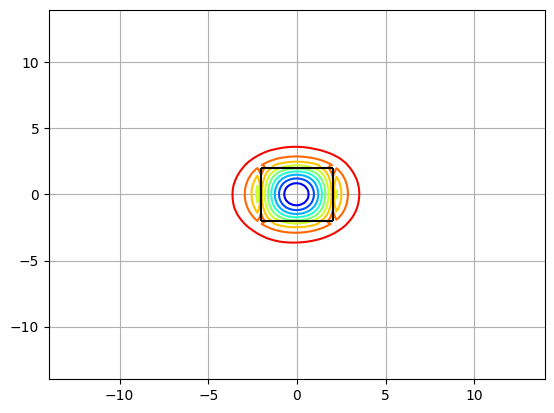

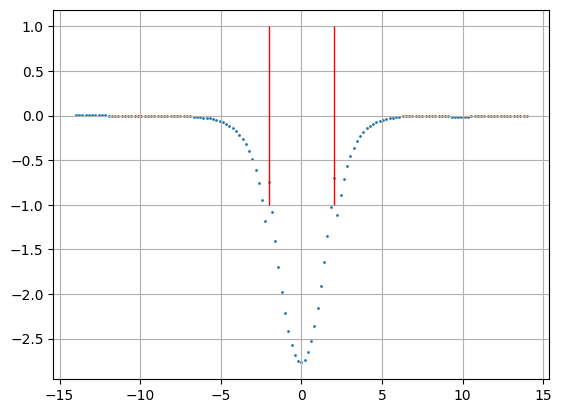

loss1 is 0.00036, loss2 is 0.00023, loss3 is 0.00024, loss4 is 0.0, loss5 is 2e-05, loss6 is 0.00118, total loss 0.00203, RI value 1.48356:  25%|██▍       | 4999/20001 [03:35<11:02, 22.63it/s]  

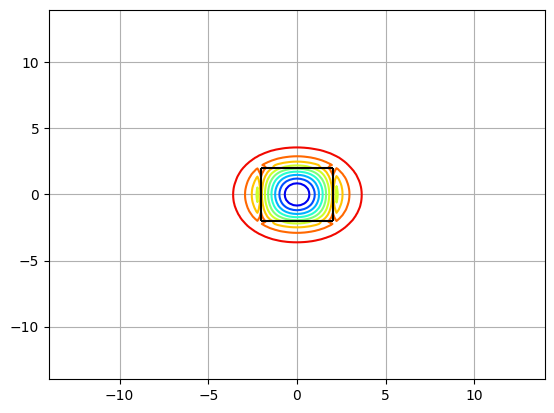

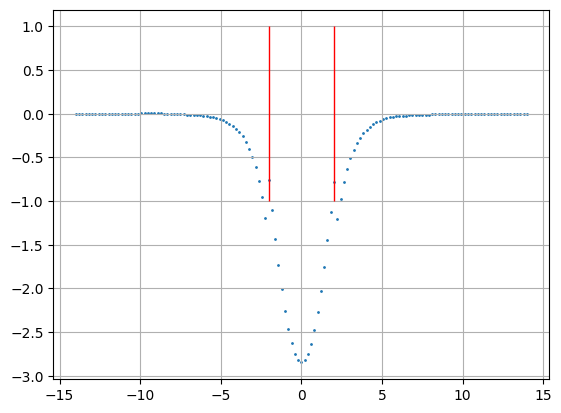

loss1 is 0.00041, loss2 is 0.0003, loss3 is 0.00027, loss4 is 0.0, loss5 is 6e-05, loss6 is 0.00116, total loss 0.0022, RI value 1.4817:  27%|██▋       | 5500/20001 [03:57<09:53, 24.45it/s]     

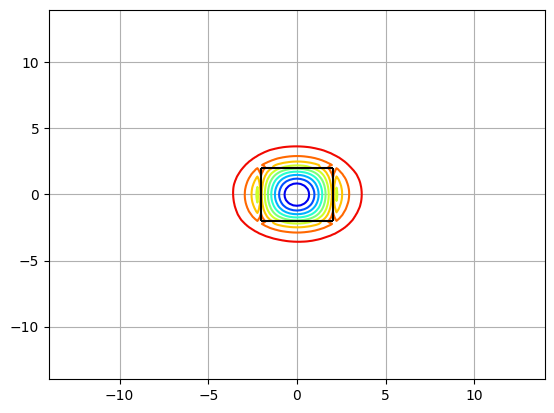

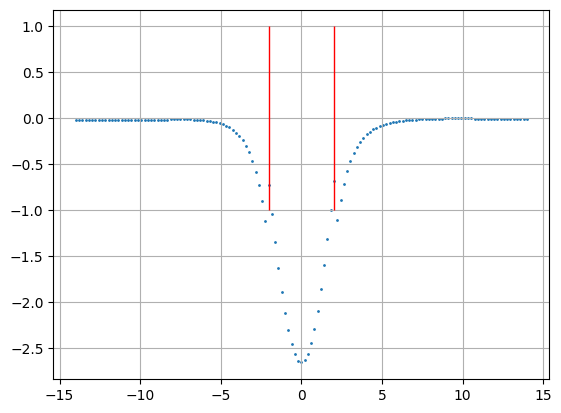

loss1 is 0.0004, loss2 is 0.00023, loss3 is 0.00026, loss4 is 0.0, loss5 is 2e-05, loss6 is 0.00127, total loss 0.00218, RI value 1.48453:  30%|██▉       | 5998/20001 [04:18<09:38, 24.21it/s]   

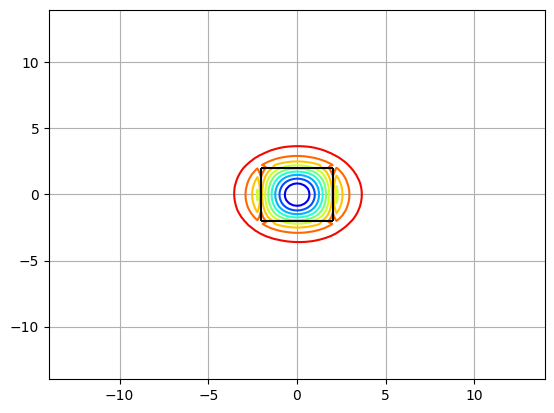

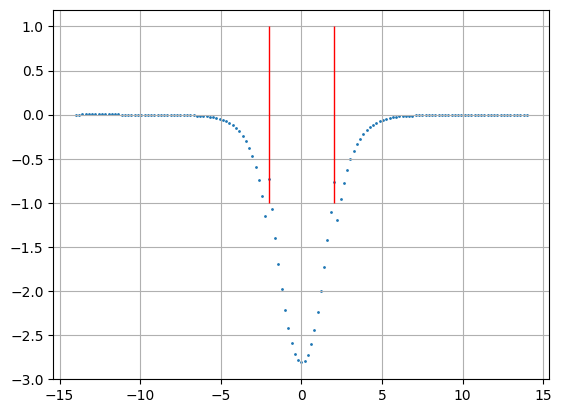

loss1 is 0.00042, loss2 is 0.00024, loss3 is 0.00028, loss4 is 0.0, loss5 is 3e-05, loss6 is 0.00103, total loss 0.002, RI value 1.48456:  32%|███▏      | 6499/20001 [04:38<09:12, 24.46it/s]    

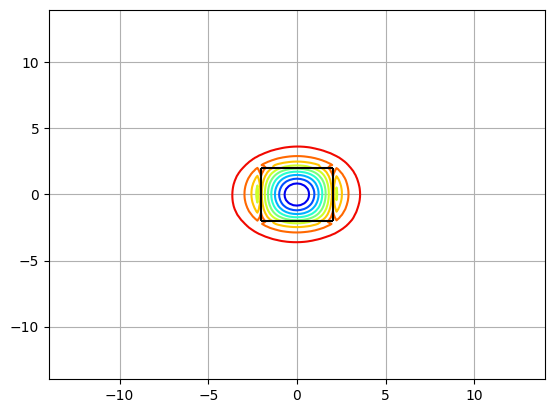

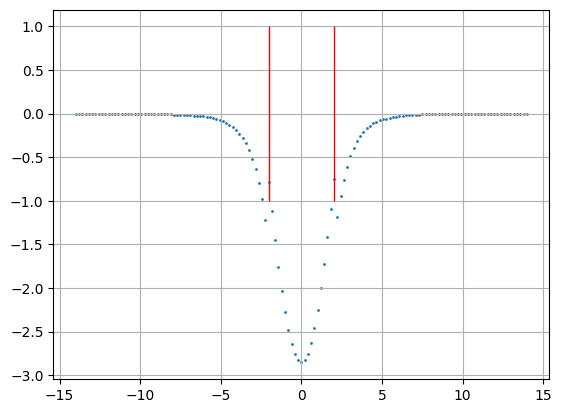

loss1 is 0.00049, loss2 is 0.00021, loss3 is 0.00032, loss4 is 0.0, loss5 is 2e-05, loss6 is 0.0011, total loss 0.00214, RI value 1.48438:  35%|███▍      | 7000/20001 [04:59<09:13, 23.48it/s]   

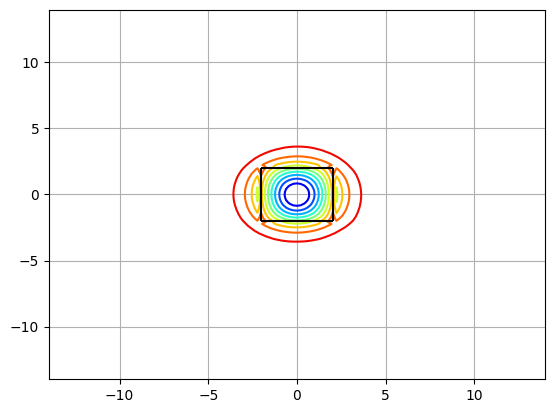

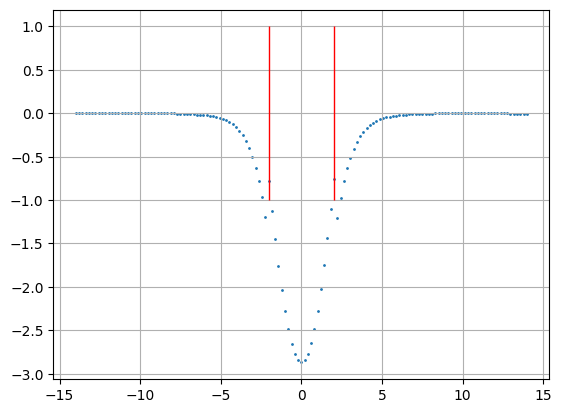

loss1 is 0.00035, loss2 is 0.00021, loss3 is 0.00023, loss4 is 0.0, loss5 is 5e-05, loss6 is 0.00113, total loss 0.00196, RI value 1.48424:  37%|███▋      | 7498/20001 [05:20<08:37, 24.16it/s]  

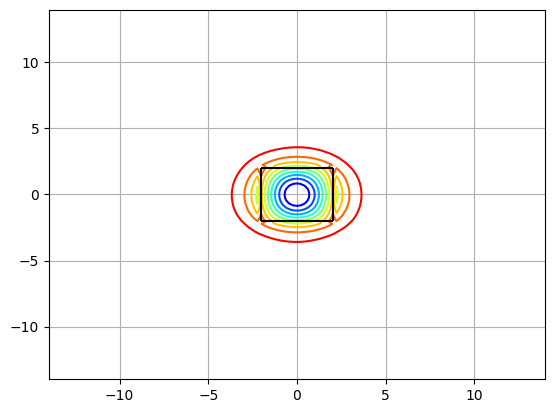

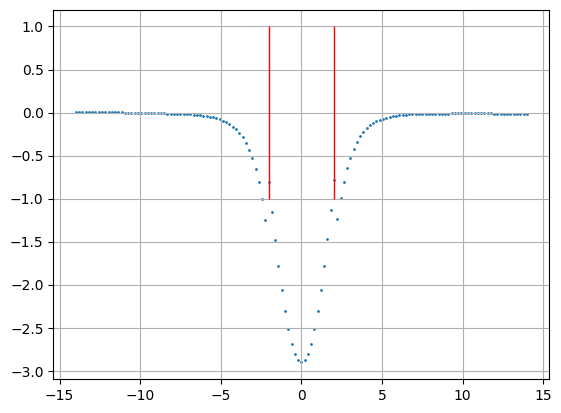

loss1 is 0.00059, loss2 is 0.00023, loss3 is 0.00039, loss4 is 0.0, loss5 is 0.00019, loss6 is 0.0013, total loss 0.0027, RI value 1.4811:  40%|███▉      | 7999/20001 [05:41<08:21, 23.92it/s]   

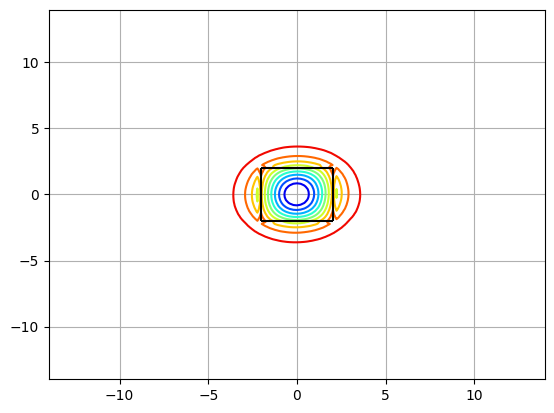

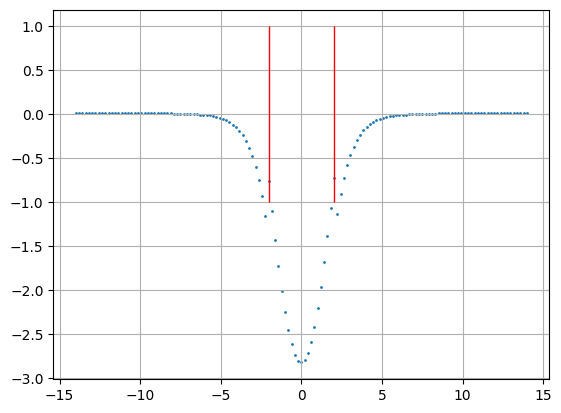

loss1 is 0.00049, loss2 is 0.0002, loss3 is 0.00032, loss4 is 0.0, loss5 is 0.00011, loss6 is 0.00112, total loss 0.00224, RI value 1.48224:  42%|████▏     | 8500/20001 [06:02<07:56, 24.12it/s] 

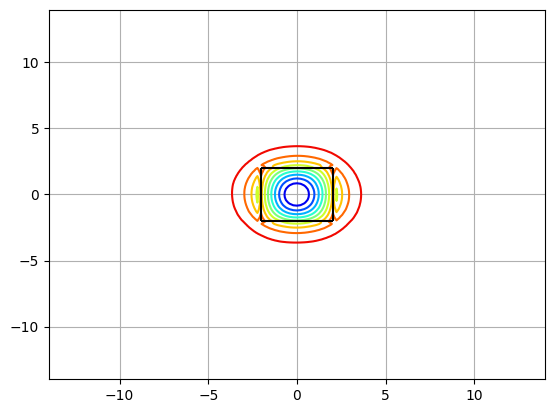

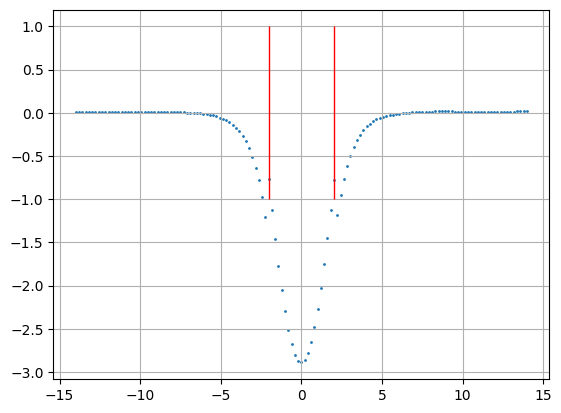

loss1 is 0.00037, loss2 is 0.00021, loss3 is 0.00024, loss4 is 0.0, loss5 is 2e-05, loss6 is 0.00112, total loss 0.00196, RI value 1.48505:  45%|████▍     | 8998/20001 [06:23<07:40, 23.89it/s]  

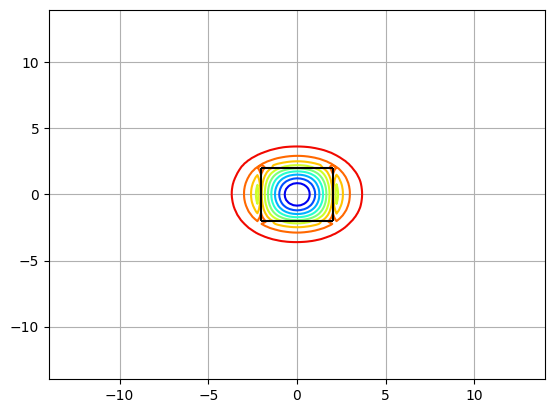

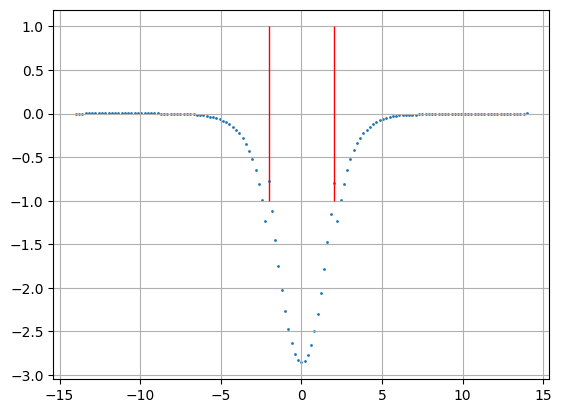

loss1 is 0.00046, loss2 is 0.00024, loss3 is 0.0003, loss4 is 0.0, loss5 is 1e-05, loss6 is 0.00107, total loss 0.00208, RI value 1.4842:  47%|████▋     | 9499/20001 [06:44<07:15, 24.14it/s]    

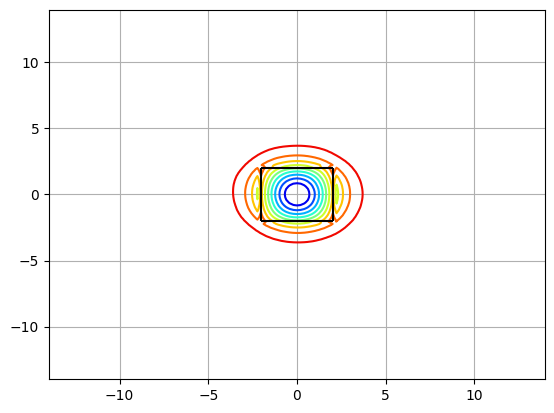

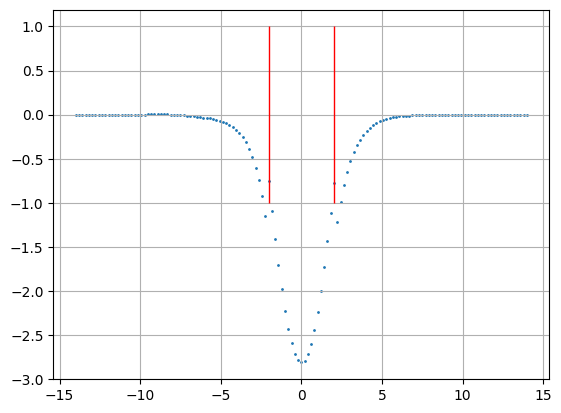

loss1 is 0.00044, loss2 is 0.00024, loss3 is 0.00029, loss4 is 0.0, loss5 is 2e-05, loss6 is 0.00103, total loss 0.002, RI value 1.48358:  50%|████▉     | 10000/20001 [07:05<06:52, 24.24it/s]   

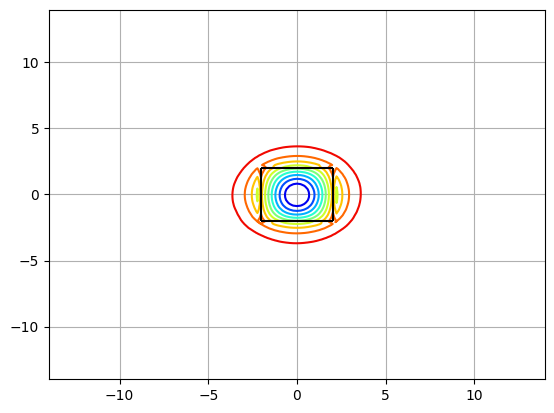

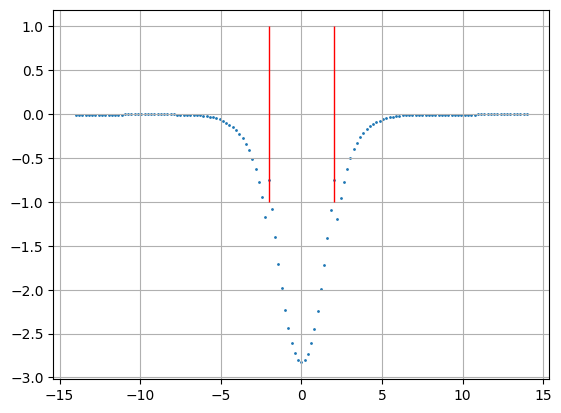

loss1 is 0.00031, loss2 is 0.00022, loss3 is 0.00021, loss4 is 0.0, loss5 is 3e-05, loss6 is 0.00107, total loss 0.00184, RI value 1.48459:  52%|█████▏    | 10498/20001 [07:27<06:47, 23.33it/s]  

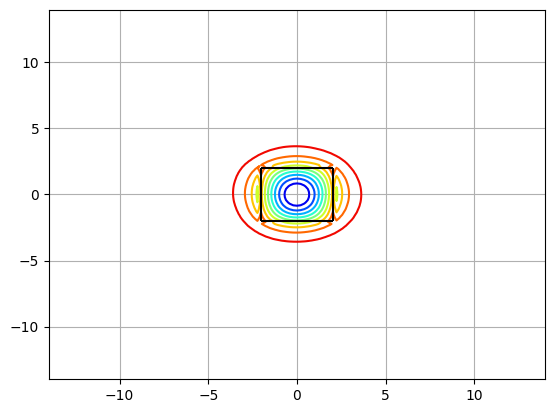

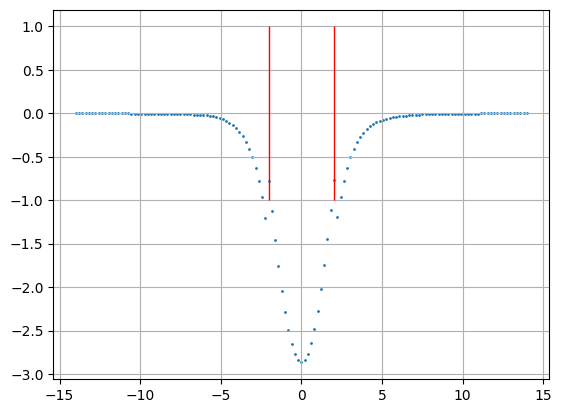

loss1 is 0.00023, loss2 is 0.00018, loss3 is 0.00015, loss4 is 0.0, loss5 is 2e-05, loss6 is 0.00123, total loss 0.00181, RI value 1.48397:  55%|█████▍    | 10999/20001 [07:48<06:15, 23.98it/s]  

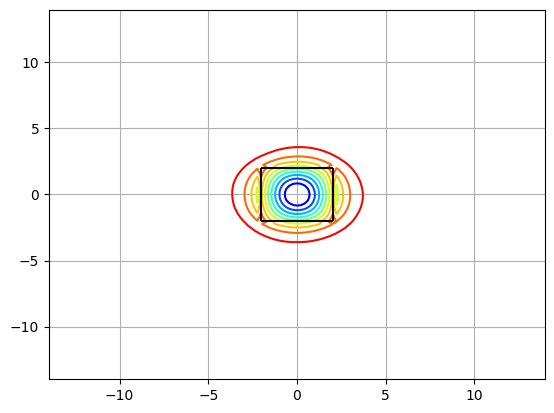

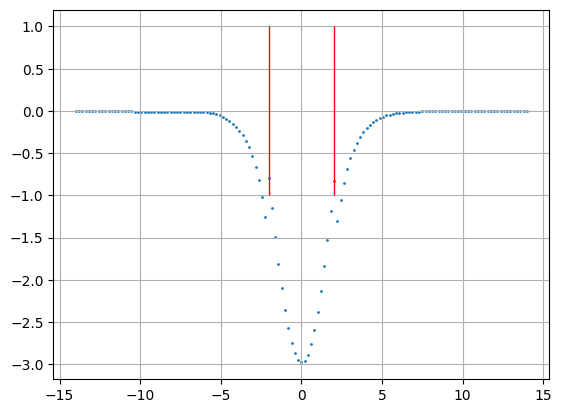

loss1 is 0.00032, loss2 is 0.00019, loss3 is 0.00021, loss4 is 0.0, loss5 is 2e-05, loss6 is 0.00119, total loss 0.00193, RI value 1.4838:  57%|█████▋    | 11500/20001 [08:09<06:01, 23.53it/s]   

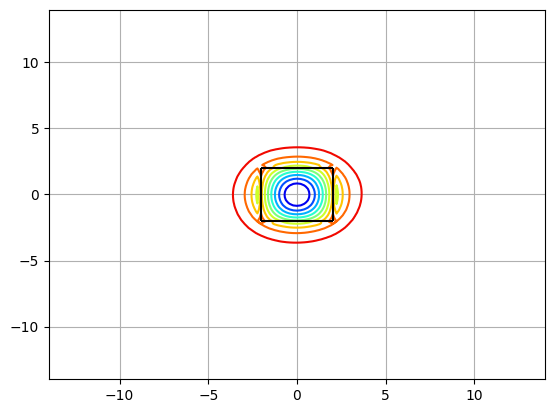

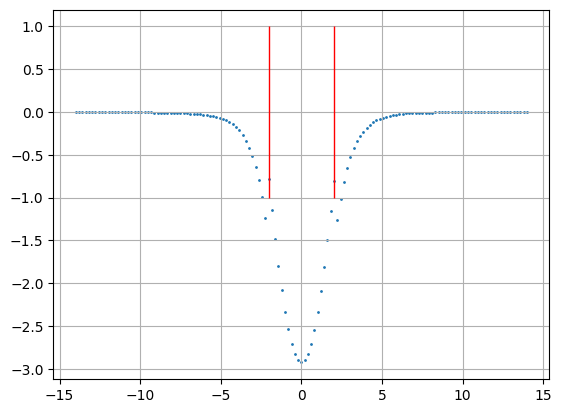

loss1 is 0.00045, loss2 is 0.00021, loss3 is 0.0003, loss4 is 0.0, loss5 is 1e-05, loss6 is 0.00116, total loss 0.00213, RI value 1.48147:  60%|█████▉    | 11998/20001 [08:30<05:35, 23.88it/s]   

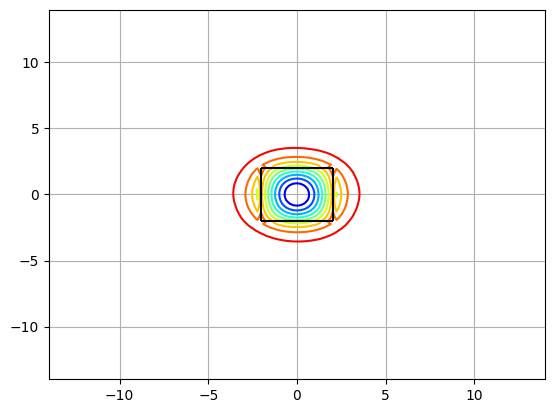

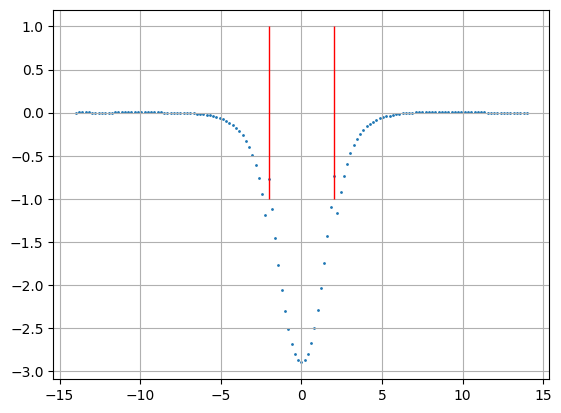

loss1 is 0.0004, loss2 is 0.00021, loss3 is 0.00026, loss4 is 0.0, loss5 is 4e-05, loss6 is 0.00103, total loss 0.00193, RI value 1.48644:  62%|██████▏   | 12499/20001 [08:51<05:16, 23.72it/s]   

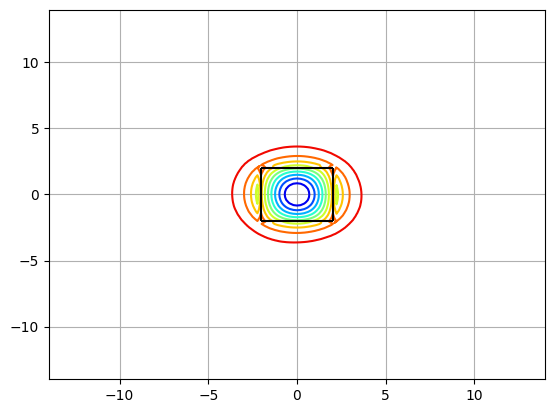

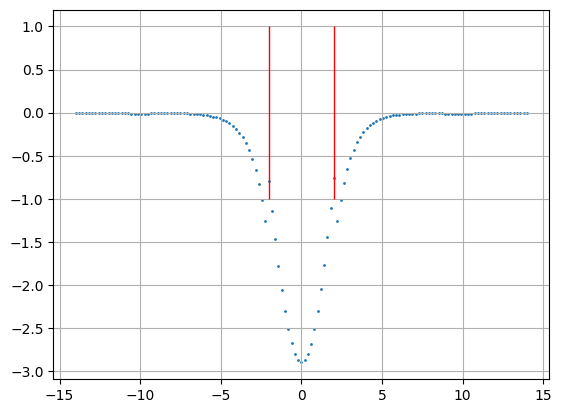

loss1 is 0.00026, loss2 is 0.0002, loss3 is 0.00017, loss4 is 0.0, loss5 is 3e-05, loss6 is 0.00114, total loss 0.0018, RI value 1.48495:  65%|██████▍   | 13000/20001 [09:12<04:52, 23.96it/s]    

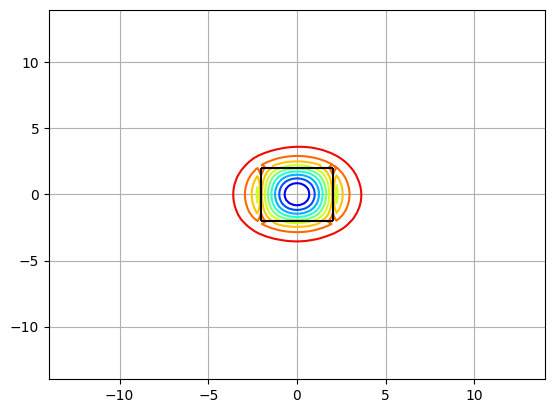

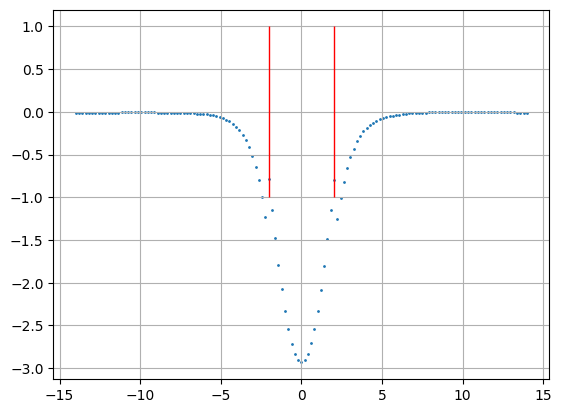

loss1 is 0.00033, loss2 is 0.0002, loss3 is 0.00022, loss4 is 0.0, loss5 is 1e-05, loss6 is 0.00107, total loss 0.00183, RI value 1.48325:  67%|██████▋   | 13498/20001 [09:34<04:33, 23.76it/s]   

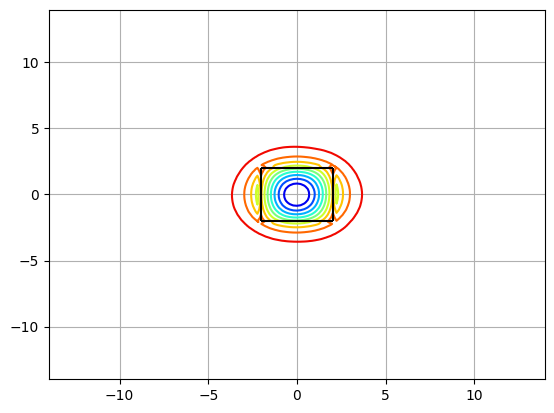

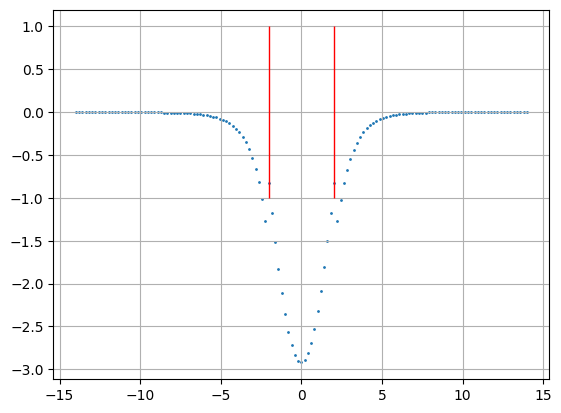

loss1 is 0.00042, loss2 is 0.0002, loss3 is 0.00027, loss4 is 0.0, loss5 is 9e-05, loss6 is 0.00114, total loss 0.00212, RI value 1.48349:  70%|██████▉   | 13998/20001 [09:55<04:18, 23.20it/s]   

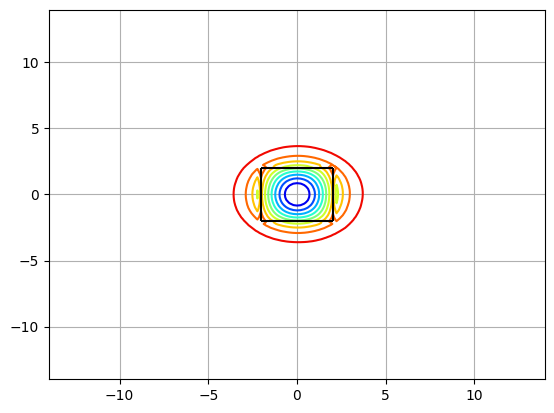

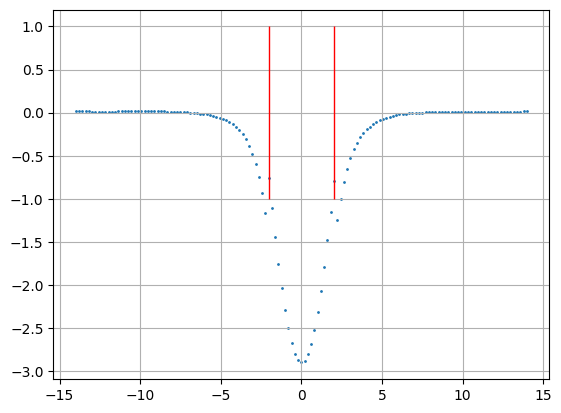

loss1 is 0.00045, loss2 is 0.00022, loss3 is 0.00029, loss4 is 0.0, loss5 is 0.0001, loss6 is 0.00112, total loss 0.00218, RI value 1.48287:  72%|███████▏  | 14499/20001 [10:17<03:52, 23.63it/s] 

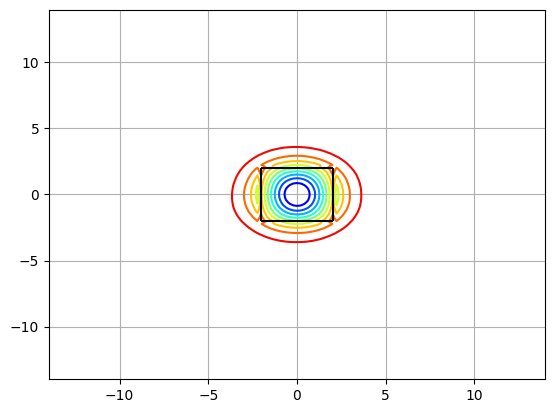

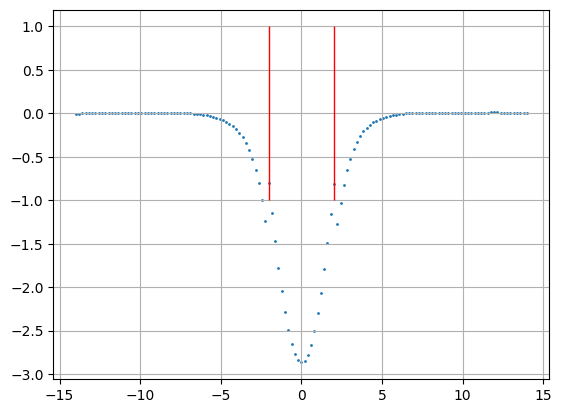

loss1 is 0.00045, loss2 is 0.0002, loss3 is 0.00029, loss4 is 0.0, loss5 is 4e-05, loss6 is 0.00116, total loss 0.00214, RI value 1.48336:  75%|███████▍  | 15000/20001 [10:38<03:30, 23.81it/s]   

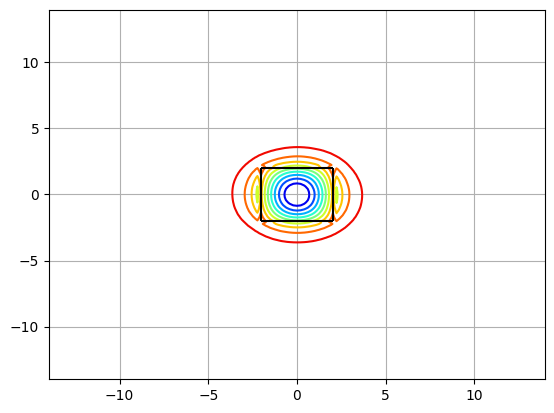

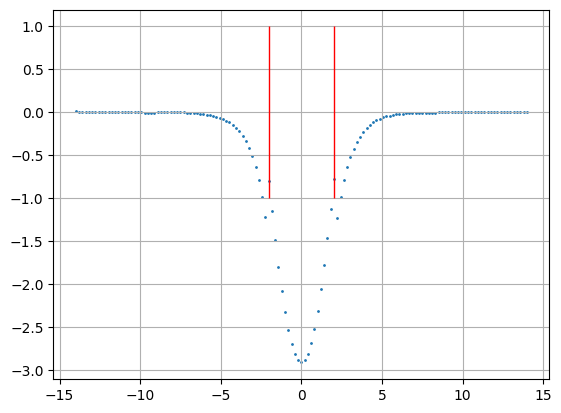

loss1 is 0.00035, loss2 is 0.0002, loss3 is 0.00023, loss4 is 0.0, loss5 is 2e-05, loss6 is 0.0011, total loss 0.00191, RI value 1.48316:  77%|███████▋  | 15498/20001 [10:59<03:06, 24.11it/s]    

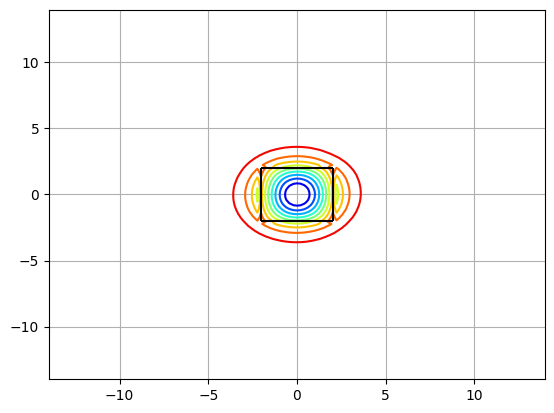

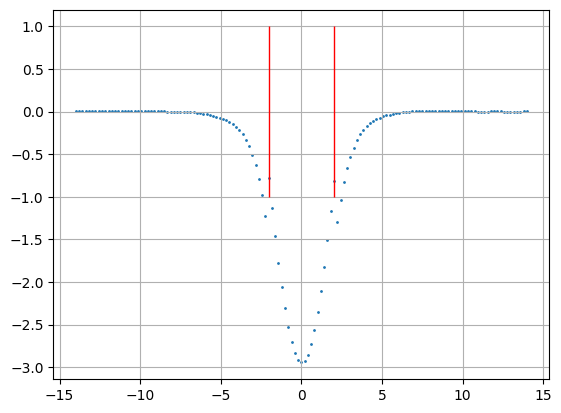

loss1 is 0.00038, loss2 is 0.00018, loss3 is 0.00025, loss4 is 0.0, loss5 is 8e-05, loss6 is 0.00107, total loss 0.00195, RI value 1.4834:  80%|███████▉  | 15999/20001 [11:20<02:48, 23.71it/s]   

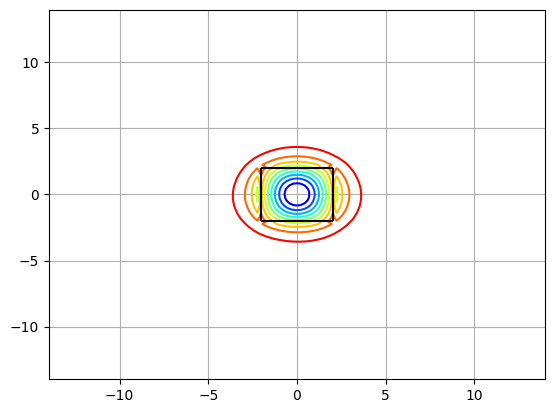

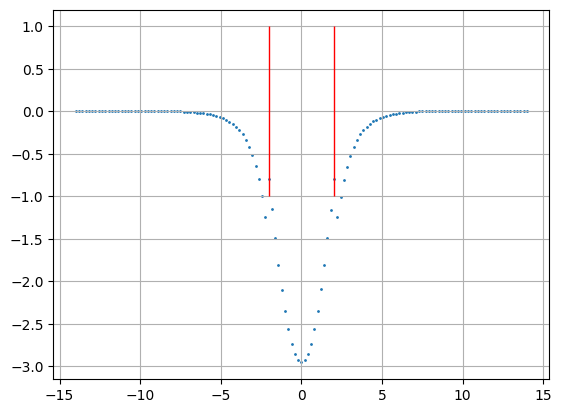

loss1 is 0.00036, loss2 is 0.00021, loss3 is 0.00024, loss4 is 0.0, loss5 is 4e-05, loss6 is 0.00118, total loss 0.00203, RI value 1.48419:  82%|████████▏ | 16500/20001 [11:42<02:30, 23.24it/s]  

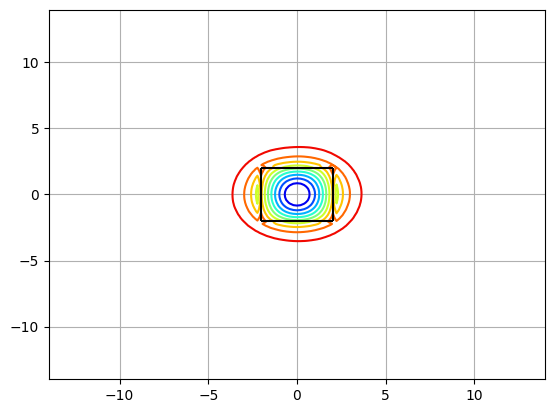

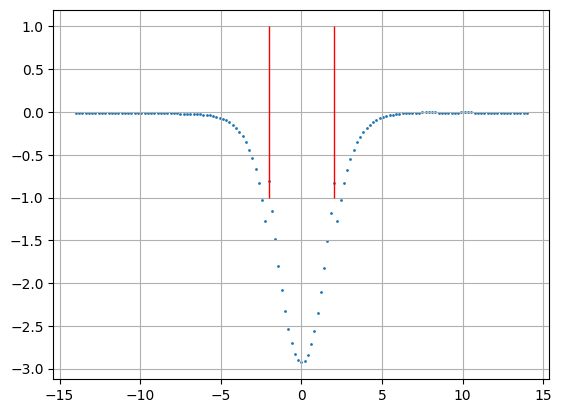

loss1 is 0.0003, loss2 is 0.00017, loss3 is 0.0002, loss4 is 0.0, loss5 is 5e-05, loss6 is 0.00115, total loss 0.00185, RI value 1.48352:  85%|████████▍ | 16998/20001 [12:03<02:04, 24.08it/s]    

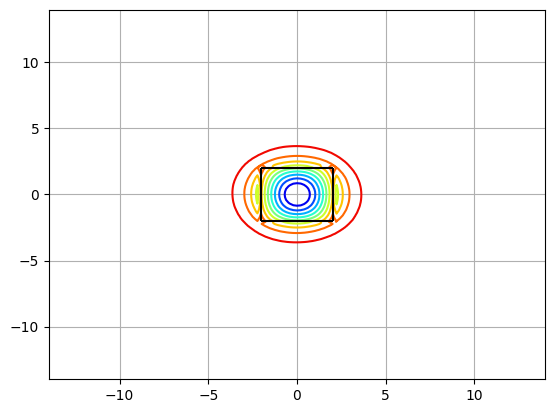

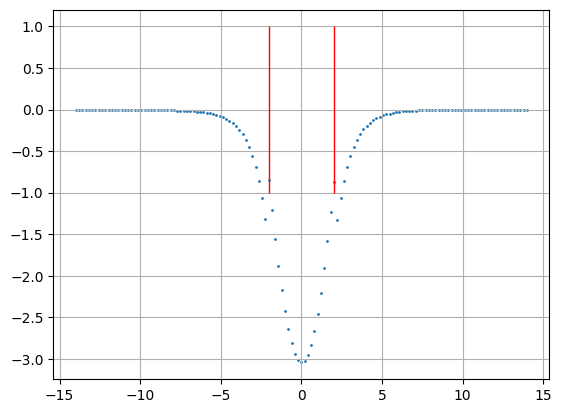

loss1 is 0.00032, loss2 is 0.00018, loss3 is 0.00021, loss4 is 0.0, loss5 is 3e-05, loss6 is 0.0011, total loss 0.00185, RI value 1.48309:  87%|████████▋ | 17499/20001 [12:24<01:45, 23.80it/s]   

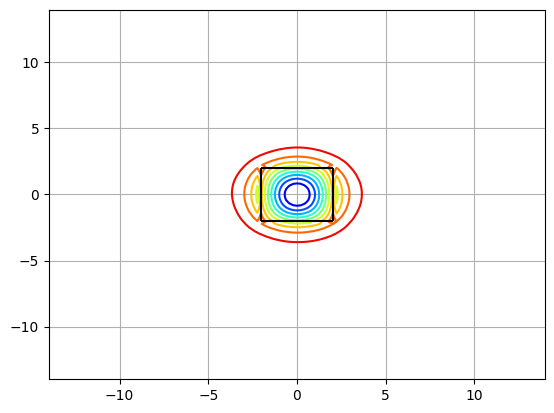

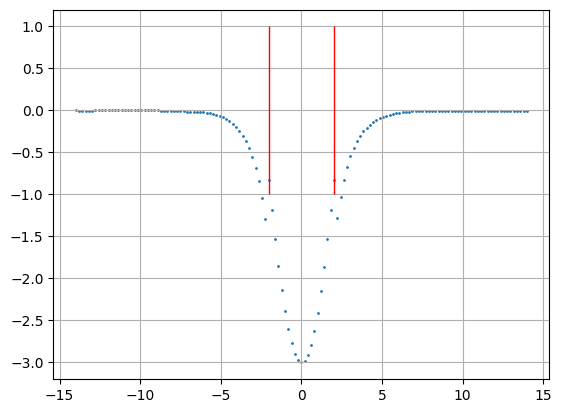

loss1 is 0.00027, loss2 is 0.00018, loss3 is 0.00018, loss4 is 0.0, loss5 is 3e-05, loss6 is 0.00109, total loss 0.00174, RI value 1.48468:  90%|████████▉ | 18000/20001 [12:45<01:22, 24.34it/s]  

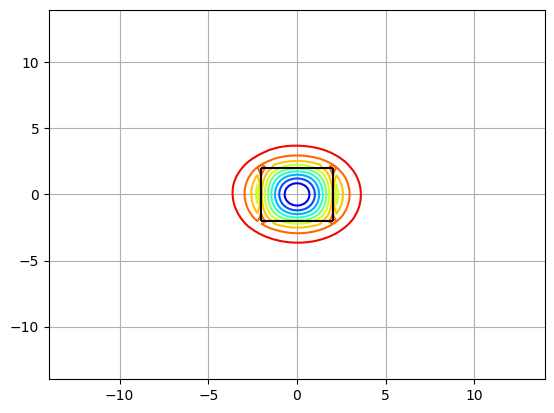

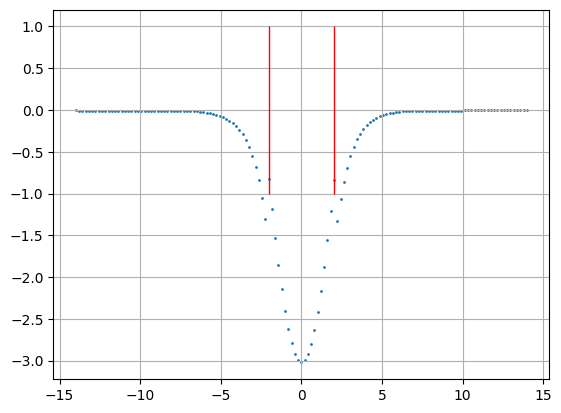

loss1 is 0.00036, loss2 is 0.00018, loss3 is 0.00024, loss4 is 0.0, loss5 is 4e-05, loss6 is 0.00116, total loss 0.00198, RI value 1.48424:  92%|█████████▏| 18498/20001 [13:07<01:03, 23.78it/s]  

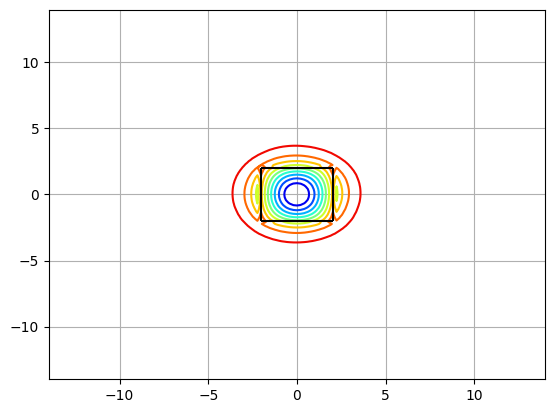

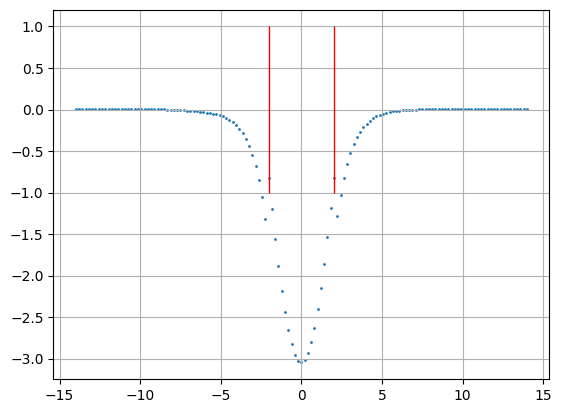

loss1 is 0.00104, loss2 is 0.00018, loss3 is 0.00068, loss4 is 0.0, loss5 is 1e-05, loss6 is 0.00112, total loss 0.00303, RI value 1.48195:  95%|█████████▍| 18999/20001 [13:28<00:42, 23.84it/s]  

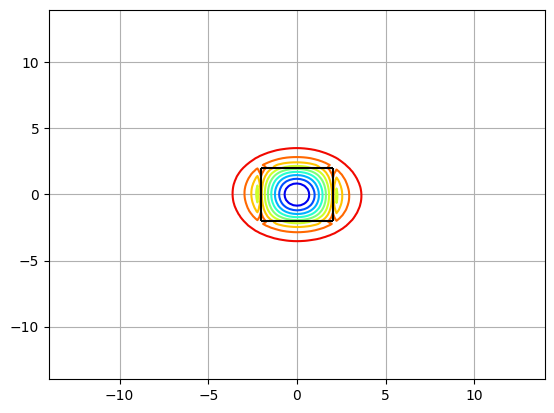

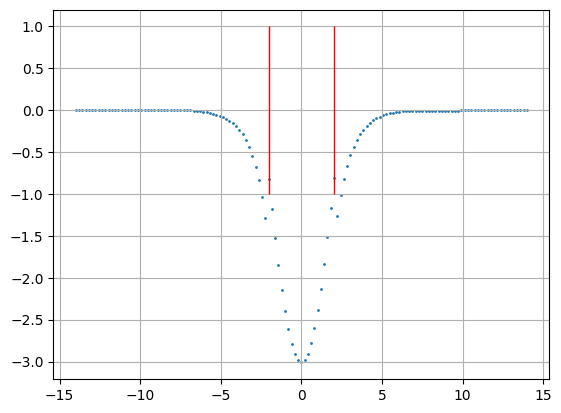

loss1 is 0.00029, loss2 is 0.00018, loss3 is 0.00019, loss4 is 0.0, loss5 is 1e-05, loss6 is 0.00118, total loss 0.00185, RI value 1.48318:  97%|█████████▋| 19500/20001 [13:49<00:21, 23.00it/s]  

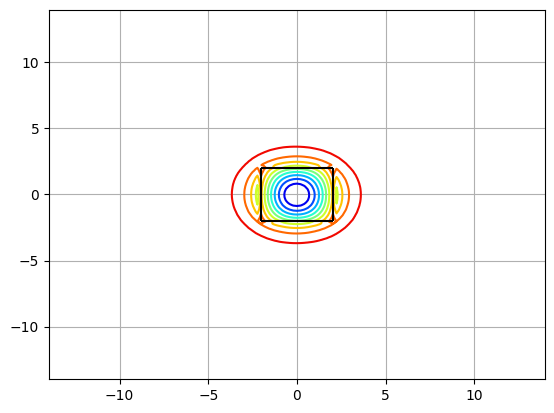

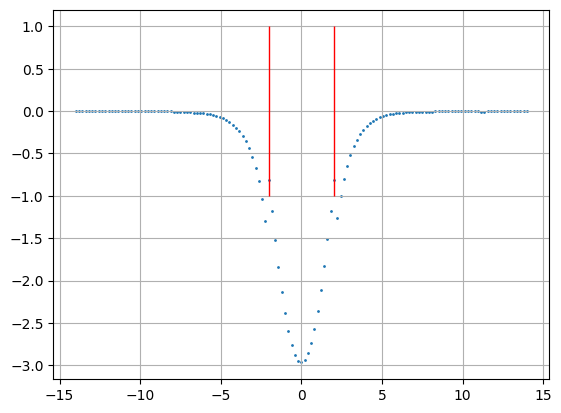

loss1 is 0.00019, loss2 is 0.00017, loss3 is 0.00012, loss4 is 0.0, loss5 is 1e-05, loss6 is 0.00105, total loss 0.00154, RI value 1.48454: 100%|█████████▉| 19998/20001 [14:11<00:00, 23.80it/s]  

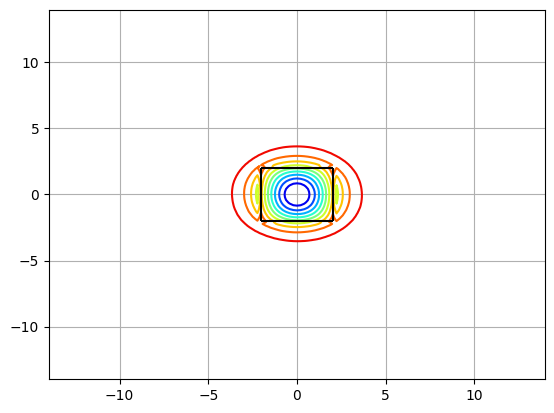

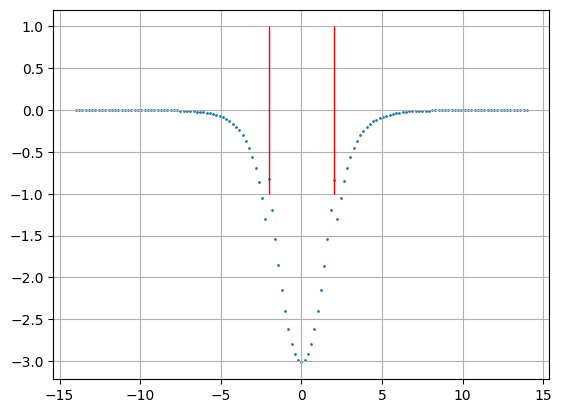

loss1 is 0.00019, loss2 is 0.00017, loss3 is 0.00012, loss4 is 0.0, loss5 is 1e-05, loss6 is 0.00105, total loss 0.00154, RI value 1.48454: 100%|██████████| 20001/20001 [14:11<00:00, 23.50it/s]


In [515]:
loss_history, rayleigh_history, mode_errors_list = train_agent.train(20001, num_modes, weights=weights, m=m, verbose=10, calc_error=False, plot_solution=True, sample_new=False)  

In [541]:
base_model.to('cpu');
base_model.to(torch.float64);

In [542]:
yu = torch.arange(0, reference_device.total_length_y/2, dy/2, dtype=torch.float64, device='cpu').reshape(-1, 1)
end_val_yu = yu[-1]
yb = torch.arange(0, reference_device.total_length_y/2, dy/2, dtype=torch.float64, device='cpu').reshape(-1, 1)
end_val_yb = yb[-1]
xy_line = torch.cat((torch.flip(-yb, dims=(0,))[:-1], yu))

xy_line = torch.cat((torch.full_like(xy_line, 0), xy_line), dim=-1)
if device.augmented_input:
  xy_line = torch.cat((xy_line, (reference_device.make_features(xy_line).view(-1, 1))), dim=-1)
u = base_model(xy_line)[:, [0]]
u = u.detach().numpy()/torch.abs(u).max(dim=0, keepdim=True)[0].detach()#%%

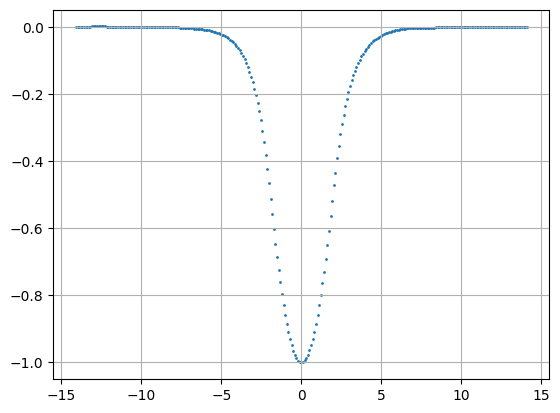

In [543]:
plt.scatter(xy_line[:, 1].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()

In [553]:
xy_line = torch.arange(0, device.total_length_x/2, dx, dtype=torch.float64).reshape(-1, 1)
xy_line = torch.cat((-torch.flip(xy_line, dims=(0,))[:-1], xy_line))

xy_line = torch.cat((xy_line, torch.full_like(xy_line, 0*dx)), dim=-1)
if device.augmented_input:
  xy_line = torch.cat((xy_line, (reference_device.make_features(xy_line).view(-1, 1))), dim=-1)
u = base_model(xy_line.cpu()).cpu()[:, [0]]
u = u.detach().numpy()/torch.abs(u).max(dim=0, keepdim=True)[0].detach()

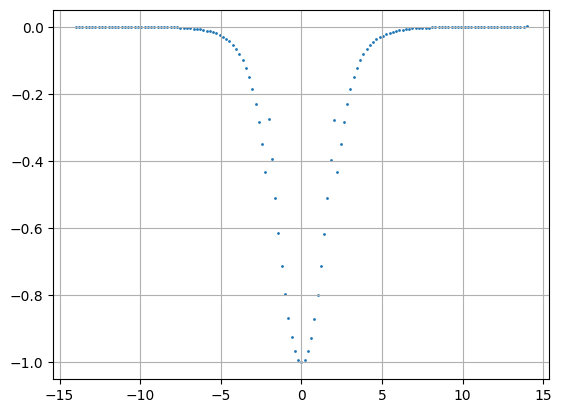

In [554]:
plt.scatter(xy_line[:, 0].cpu().detach(), u, s=1)
plt.grid()

In [555]:
len(xy_line[:])

139

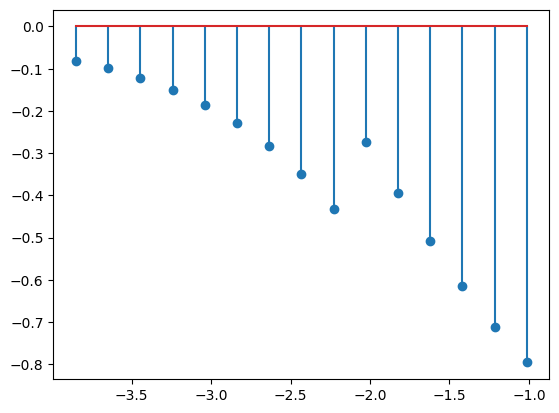

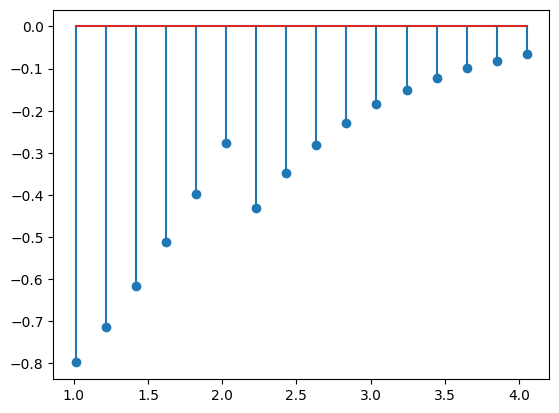

In [556]:
plt.stem(xy_line[50:65, 0].detach().numpy(), u[50:65, 0].detach().numpy())
plt.show()
plt.stem(xy_line[75-1:90, 0].detach().numpy(), u[75-1:90, 0].detach().numpy())
plt.show()

In [1]:
reference_device_fd = devices.BuriedChannelWaveguideWithFD(RIs, lambd, lengths_x, lengths_y, study, 'E', dx/4, dy/4, num_modes=num_modes)

NameError: name 'devices' is not defined

In [533]:
RI_squared, xy_fd, u_fd = reference_device_fd.evaluate()
xy_fd = torch.from_numpy(xy_fd).to(torch.float64)
xy = torch.cat((xy_fd, device.make_features(xy_fd)), dim=-1)

print(np.sqrt(RI_squared))

[1.49198225]


In [443]:
# xy.requires_grad = True
# 
# NN_EI = [device.calculate_eigen_value(xy.to('cpu'), 0).item()**(1/2)]
# print(NN_EI)
# xy.requires_grad = False

In [444]:
Nx = int(sum(lengths_x)//(dx/2))
Ny = int(sum(lengths_y)//(dy/2))

print(len(u_fd), Nx*Ny)

312481 77841


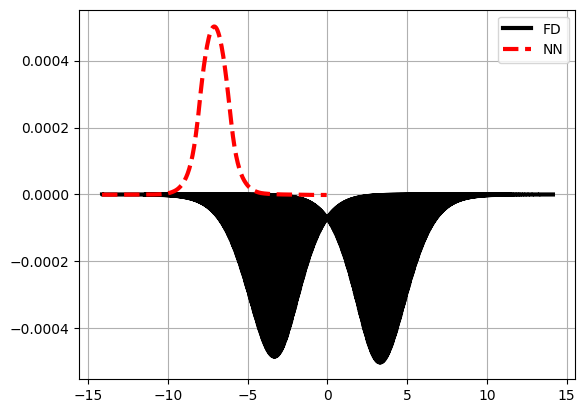

In [445]:
i = 0
row_length = Nx
plt.plot(xy_fd[row_length * i + row_length // 2::row_length, 1], -u_fd[row_length * i + row_length // 2::row_length, 0], linewidth=3, label='FD', color='black')
plt.plot(xy_fd[row_length * i: row_length * (i + 1), 0], -u*np.max(np.abs(u_fd[row_length * i + row_length // 2::row_length, 0])), linestyle='dashed', label='NN', color='red', linewidth=3)
plt.legend()
plt.grid()

In [446]:
# i = int(Ny//2)
# row_length = Nx
# plt.plot(xy_fd[row_length * i: row_length * (i + 1), 0], u_fd[row_length * i:row_length * (i + 1), 0], linewidth=3, label='FD', color='black')
# plt.plot(xy_fd[row_length * i: row_length * (i + 1), 0], u*np.max(np.abs(u_fd[row_length * i:row_length * (i + 1), 0])), linestyle='dashed', label='NN', color='red', linewidth=3)
# plt.legend()
# plt.grid()

In [534]:
# ratio_fd = u_fd[row_length * i:row_length * (i + 1), 0]/u_fd[row_length * i - 1: row_length * (i + 1)-1, 0]
# half_index = len(ratio_fd)//2
# quarter_index = len(ratio_fd)//4
# xy_fd_slice = xy_fd[row_length * i:row_length * (i + 1)][half_index-quarter_index:half_index+quarter_index+1]
# 
# u = train_agent.evaluate(xy_fd_slice.cpu())[:, [0]]
# u = u.detach().numpy()/torch.abs(u).max(dim=0, keepdim=True)[0].detach()
# ratio_nn = u[1:]/u[0:-1]
# 
# plt.figure(figsize=(10, 10))
# plt.plot(xy_fd_slice[:, 0], ratio_fd[half_index-quarter_index:half_index+quarter_index+1], label='FD', linewidth=3)
# 
# # plt.stem(xy[50:65, 0].detach().numpy(), -u[50:65, 0].detach().numpy())
# # plt.show()
# # plt.stem(xy[75-1:90, 0].detach().numpy(), -u[75-1:90, 0].detach().numpy())
# # plt.show()
# plt.plot(xy_fd_slice[1:, 0], ratio_nn, linestyle='--', label='NN', linewidth=3)
# plt.axhline(y=(n_core**2)/(n_substrate**2), linewidth=3)
# plt.axhline(y=(n_substrate**2)/(n_core**2), linewidth=3)
# plt.ylim([(n_substrate**2)/(n_core**2)*0.95, (n_core**2)/(n_substrate**2)*1.05])
# plt.grid()
# plt.legend()

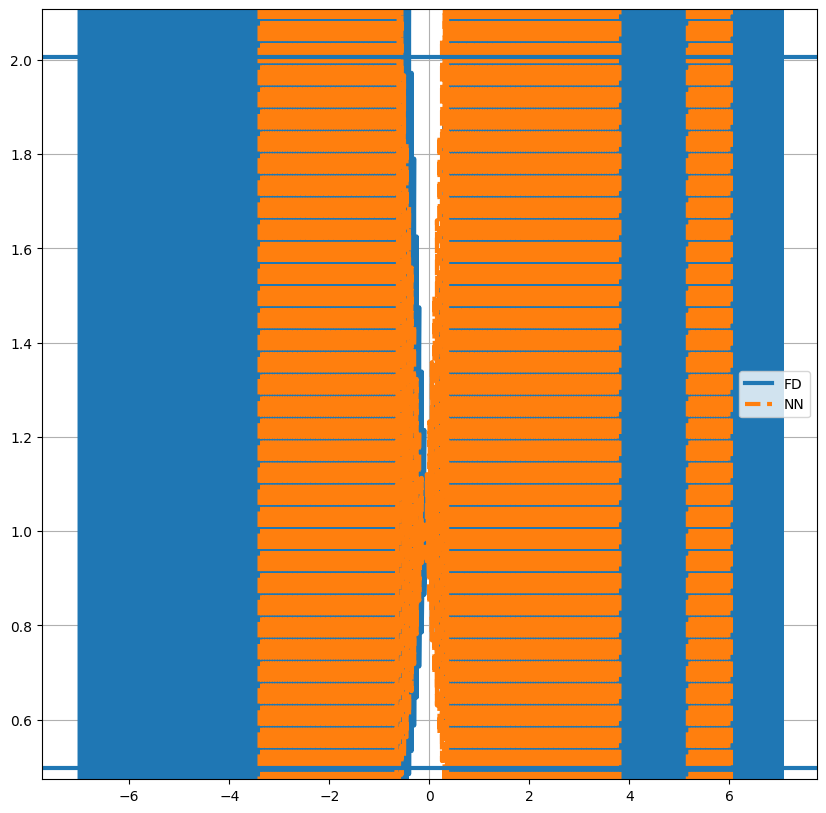

In [535]:
ratio_fd = u_fd[row_length * (i+1) + row_length // 2::row_length, 0]/u_fd[row_length * i + row_length // 2::row_length, 0][:-1]
half_index = len(ratio_fd)//2
quarter_index = len(ratio_fd)//4
xy_fd_slice = xy_fd[row_length * (i+1) + row_length // 2::row_length][half_index-quarter_index:half_index+quarter_index+1]

u = train_agent.evaluate(xy_fd_slice.cpu())[:, [0]]
u = u.detach().numpy()/torch.abs(u).max(dim=0, keepdim=True)[0].detach()
ratio_nn = u[1:]/u[0:-1]

plt.figure(figsize=(10, 10))
plt.plot(xy_fd_slice[:, 1], ratio_fd[half_index-quarter_index:half_index+quarter_index+1], label='FD', linewidth=3)

# plt.stem(xy[50:65, 0].detach().numpy(), -u[50:65, 0].detach().numpy())
# plt.show()
# plt.stem(xy[75-1:90, 0].detach().numpy(), -u[75-1:90, 0].detach().numpy())
# plt.show()
plt.plot(xy_fd_slice[1:, 1], ratio_nn, linestyle='--', label='NN', linewidth=3)
plt.axhline(y=(n_core**2)/(n_substrate**2), linewidth=3)
plt.axhline(y=(n_substrate**2)/(n_core**2), linewidth=3)
plt.ylim([(n_substrate**2)/(n_core**2)*0.95, (n_core**2)/(n_substrate**2)*1.05])
plt.grid()
plt.legend()

In [536]:
u = base_model(xy.cpu())
u = u/torch.max(torch.abs(u))
u_fd = u_fd/np.max(np.abs(u_fd))

In [537]:
print(len(u), len(u_fd))

312481 312481


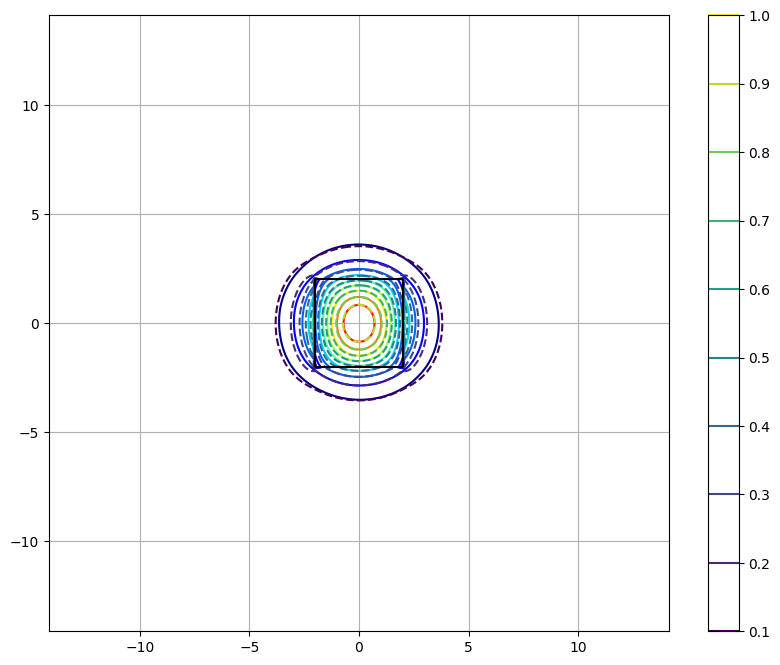

In [540]:
levels = np.linspace(0, np.max(np.abs(u_fd)), 11)[1:]
# levels =  10
plt.figure(figsize=(10, 8))
plt.tricontour(xy[:, 0].cpu().detach(), xy[:, 1].detach().cpu(), -u[:,0].detach(), cmap='jet', levels=levels)
plt.tricontour(xy_fd[:, 0], xy_fd[:, 1], u_fd[:,0], linestyles='dashed', levels=levels)
plt.vlines(-core_length_x/2, -core_length_y/2, core_length_y/2, colors='black')
plt.vlines(core_length_x/2, -core_length_y/2, core_length_y/2, colors='black')
plt.hlines(-core_length_y/2, -core_length_x/2, core_length_x/2, colors='black')
plt.hlines(core_length_y/2, -core_length_x/2, core_length_x/2, colors='black')
plt.colorbar()
plt.grid()

In [528]:
print(len(u))

77841


In [529]:
save_folder_path = r"C:\Users\asmaa\Desktop\Amr\2nd Paper\Experiments\TM"

In [324]:
# np.save(save_folder_path + r'\NonPlanar\Single Mode Moderate Contrast\DCNN_field.npy', u.detach().numpy())
# torch.save(base_model.state_dict(), save_folder_path + r'\NonPlanar\Single Mode Moderate Contrast\DCNN.pty')
# np.save(save_folder_path + r'\NonPlanar\Single Mode Moderate Contrast\NN_EI.npy', NN_EI)
# 
# 
# np.save(save_folder_path + r'\NonPlanar\Single Mode Moderate Contrast\FD_field.npy', u_fd)
# np.save(save_folder_path + r'\NonPlanar\Single Mode Moderate Contrast\FD_EI.npy', [RI_squared])